In [1]:
import argparse
from pathlib import Path
import shutil
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
def wavelength_to_rgb(wavelength, gamma=0.8):
    if wavelength < 380 or wavelength > 750:
        return (0.5, 0.5, 0.5)
    if 380 <= wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif 440 < wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0
    elif 490 < wavelength <= 510:
        R = 0.0
        G = 1.0
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif 510 < wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0
        B = 0.0
    elif 580 < wavelength <= 645:
        R = 1.0
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif 645 < wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    return (R, G, B)

def scatter_colored(df, col_Es1, col_f, title, xlab, ylab, xlim=None):
    d = df.dropna(subset=[col_Es1, col_f]).copy()
    if d.empty:
        return
    lam = 1239.841984 / d[col_Es1].values  # eV -> nm
    colors = [wavelength_to_rgb(w) for w in lam]
    fig, ax = plt.subplots(figsize=(6.6, 5.2), dpi=300)
    ax.scatter(d[col_Es1], d[col_f], c=colors, s=10)
    ax.set_title(title)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    if xlim is not None:
        ax.set_xlim(*xlim)
    return fig, ax

In [20]:
std2_df.columns

Index(['partition', 'mol', 'smiles', 'strength', 'absorption', 'E_S1_eV',
       'E_T1_eV', 'E_ST_eV', 'f_osc_S1'],
      dtype='object')

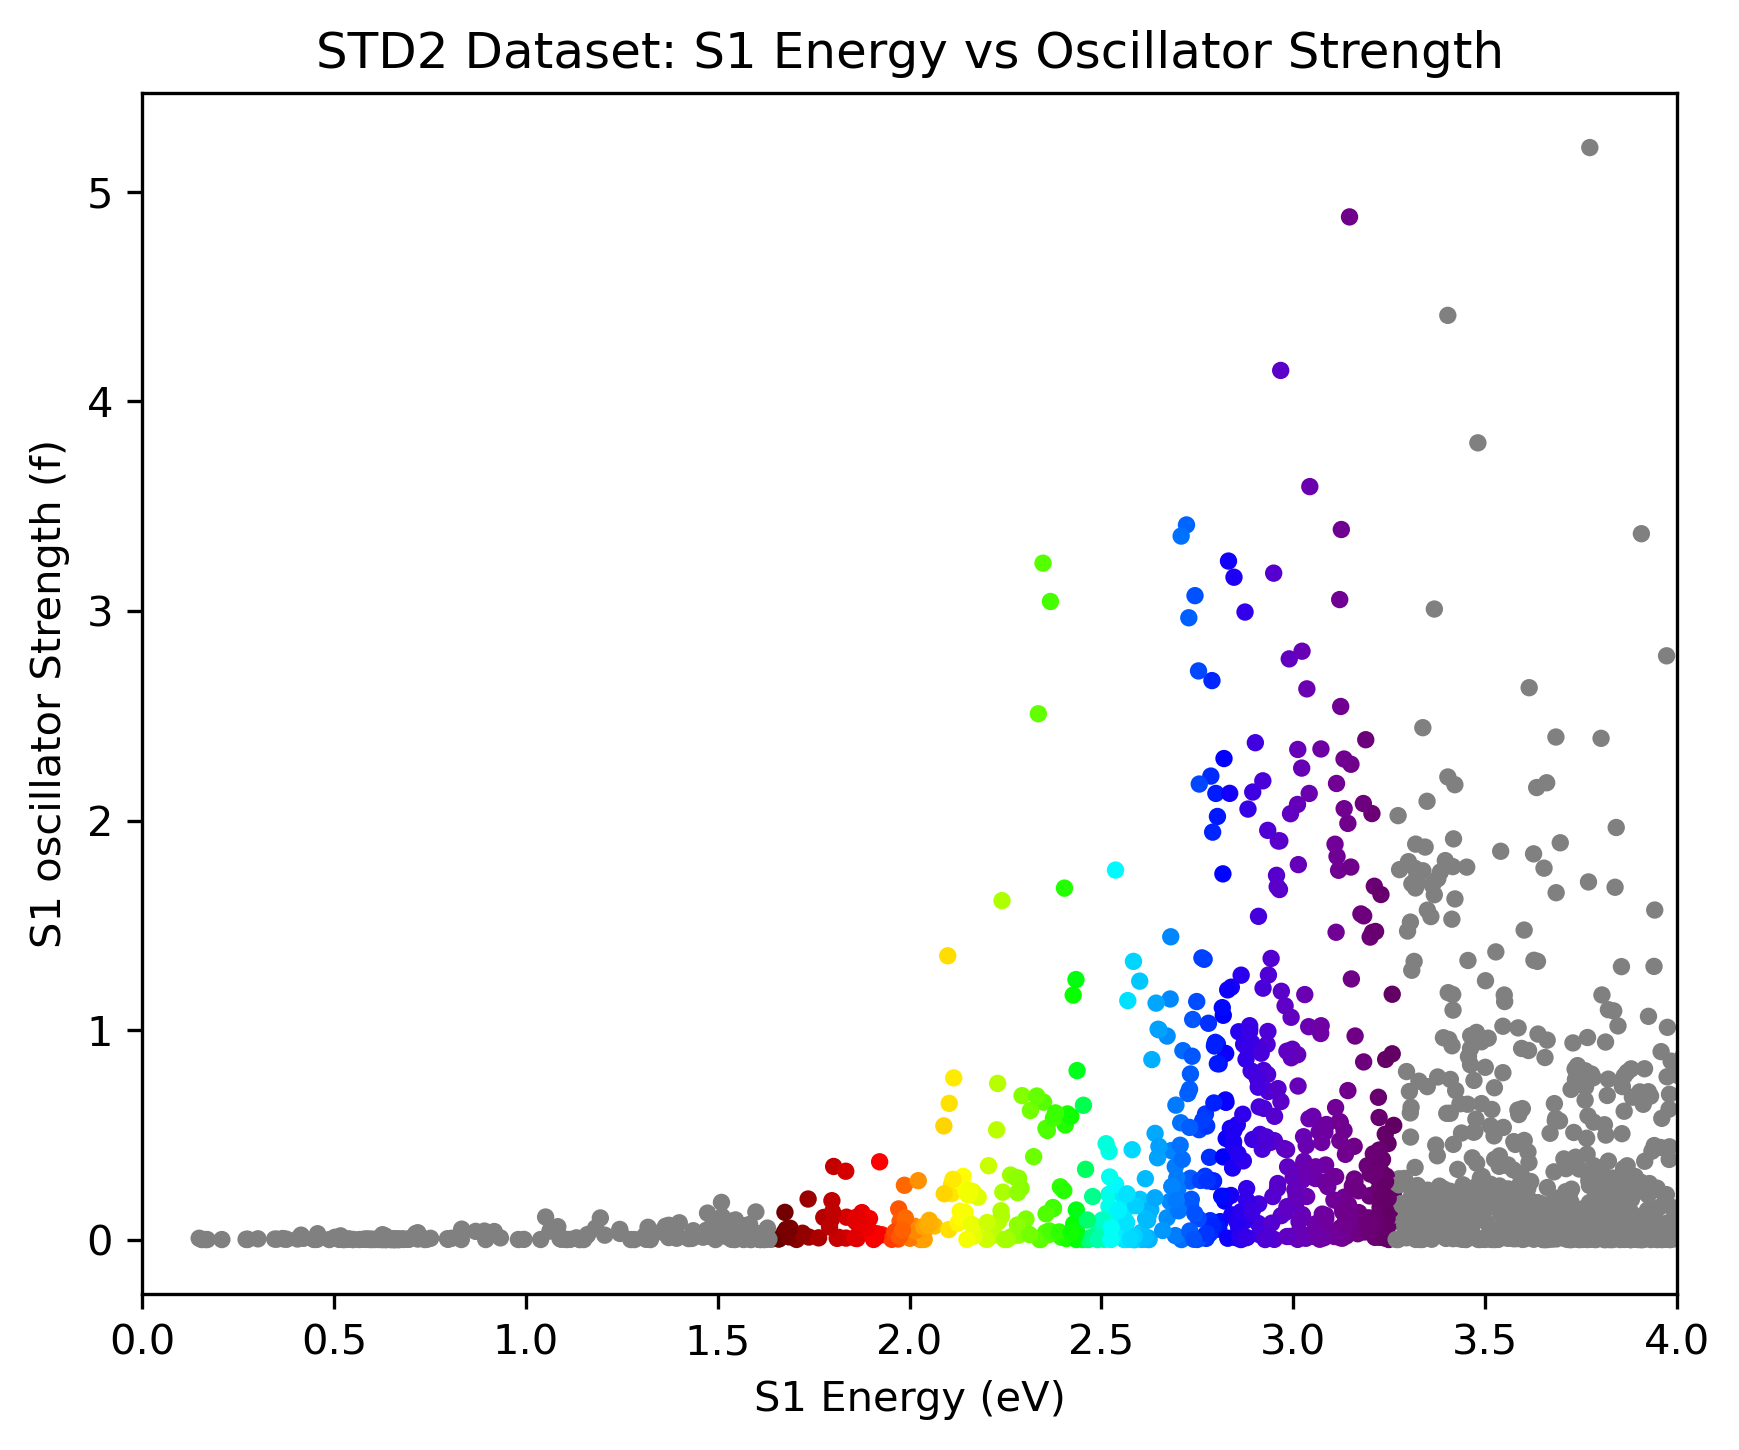

In [3]:
std2_df = pd.read_csv('results/std2/std2.csv')

fig, ax = scatter_colored(
    std2_df,
    col_Es1='E_S1_eV',
    col_f='f_osc_S1',
    title='STD2 Dataset: S1 Energy vs Oscillator Strength',
    xlab='S1 Energy (eV)',
    ylab='S1 oscillator Strength (f)',
    xlim=(0, 4.)
)

plt.show()
plt.close()

/tmp/ipykernel_26086/1259692313.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bin_interval, group in std2_df.groupby('Es1_bin'):


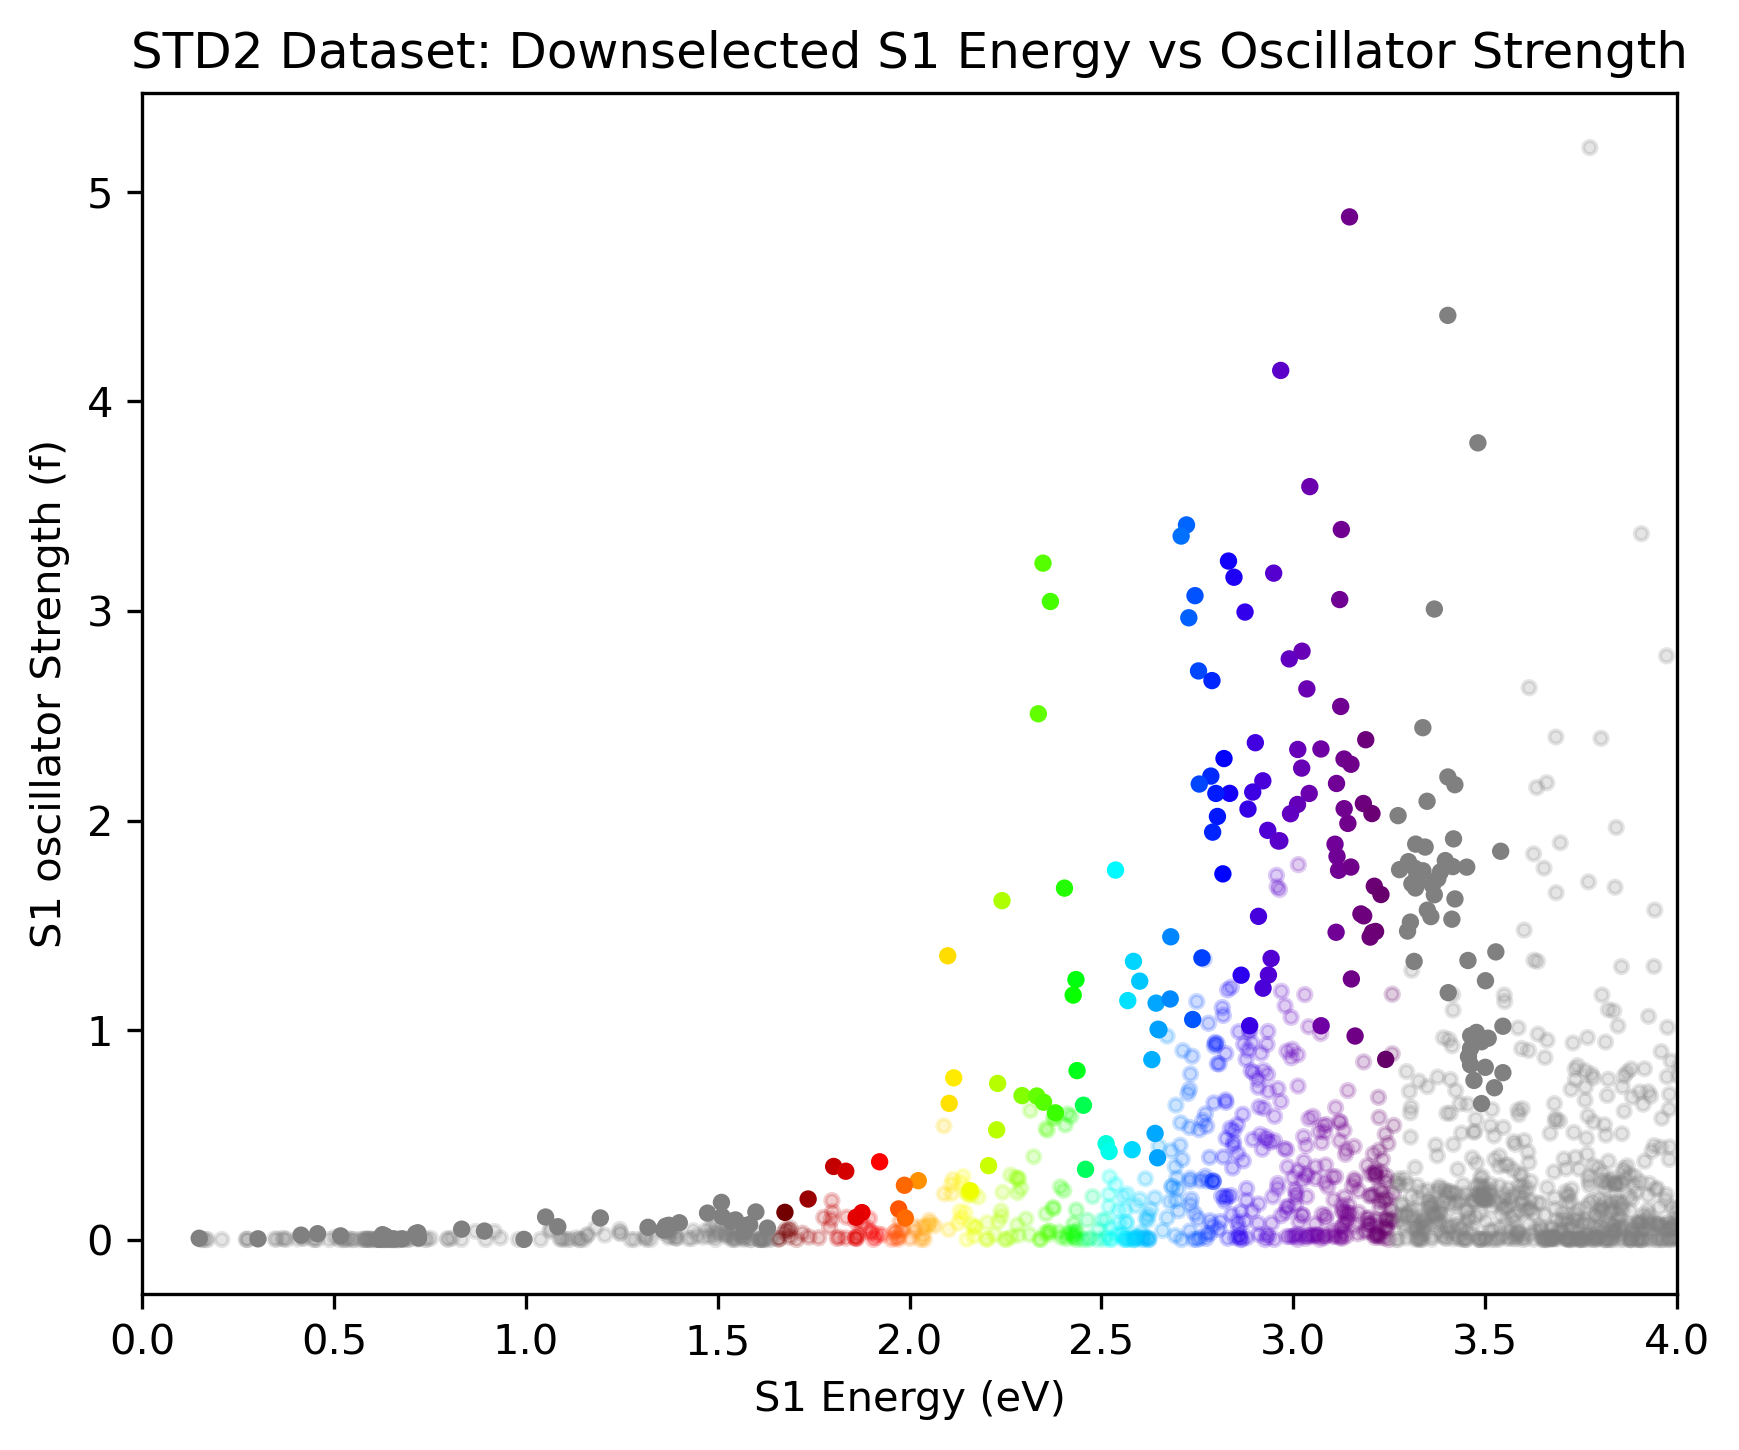

In [31]:
# Bin the data in 0.1 eV intervals and select the top 20% f_osc_S1 in each bin
# But bin in the range of the minimum vale up to 3.5 eV
# Lastly plot the downselected data and the rest of the data with lower alpha

min_Es1 = std2_df['E_S1_eV'].min()
bins = np.arange(min_Es1, 3.6, 0.1)
std2_df['Es1_bin'] = pd.cut(std2_df['E_S1_eV'], bins=bins, include_lowest=True)
downselected_indices = []
for bin_interval, group in std2_df.groupby('Es1_bin'):
    if group.empty:
        continue
    top_n = max(1, int(len(group) * 0.2))
    top_group = group.nlargest(top_n, 'f_osc_S1')
    downselected_indices.extend(top_group.index.tolist())
downselected_df = std2_df.loc[downselected_indices]
rest_df = std2_df.drop(index=downselected_indices)
fig, ax = plt.subplots(figsize=(6.6, 5.2), dpi=300)
# Plot rest of the data with lower alpha
lam_rest = 1239.841984 / rest_df['E_S1_eV'].values
colors_rest = [wavelength_to_rgb(w) for w in lam_rest]
ax.scatter(rest_df['E_S1_eV'], rest_df['f_osc_S1'], c=colors_rest, s=10, alpha=0.2)
# Plot downselected data
lam_down = 1239.841984 / downselected_df['E_S1_eV'].values
colors_down = [wavelength_to_rgb(w) for w in lam_down]
ax.scatter(downselected_df['E_S1_eV'], downselected_df['f_osc_S1'], c=colors_down, s=10)
ax.set_title('STD2 Dataset: Downselected S1 Energy vs Oscillator Strength')
ax.set_xlabel('S1 Energy (eV)')
ax.set_ylabel('S1 oscillator Strength (f)')
ax.set_xlim(0, 4.)
plt.show()
plt.close() 

In [33]:
len(downselected_indices)

209

In [36]:
final_df = std2_df.loc[downselected_indices]
final_df.to_csv('results/std2/std2_downselected.csv', index=False)


In [37]:
final_df

,partition,mol,smiles,strength,absorption,E_S1_eV,E_T1_eV,E_ST_eV,f_osc_S1,Es1_bin
1228,partition_1,mol1240,CCCCCCCCCCCCCCCN1/C(=C/C2C(=O)C(=CC3=[N+](CCCC...,3,3,0.1482,0.3258,-0.1776,0.006189,"(0.147, 0.248]"
893,partition_0,mol0899,CC1=c2c(nc3c4ccccc4c4cccc4n23)C=C1,2,2,0.3014,0.3297,-0.0283,0.003503,"(0.248, 0.348]"
865,partition_0,mol0870,O=C(c1ccccc1)c1ccc(-n2c3ccccc3c3cc4cccc4c4ccc2...,2,1,0.4138,0.0357,0.3781,0.021168,"(0.348, 0.448]"
1215,partition_1,mol1226,O=[C]([Cd])c1c2ccccc2cc2ccccc12,3,3,0.4568,0.4568,0.0000,0.027958,"(0.448, 0.548]"
815,partition_0,mol0820,CCCC1=CC2=Cc3[nH]c(cc3CCC)C3=NC(=c4cc(CCC)c([n...,2,0,0.5169,0.1044,0.4125,0.017584,"(0.448, 0.548]"
...,...,...,...,...,...,...,...,...,...,...
1678,partition_1,mol1696,C1=C2C=C(c3ccccc3)c3ccccc3B2Nc2ccccc21,4,3,3.5007,2.5728,0.9279,0.822071,"(3.448, 3.548]"
894,partition_0,mol0900,Cc1cccc(C2=Cc3cccc[n+]3[B-](F)(F)O2)c1,2,2,3.5466,2.5782,0.9684,0.796451,"(3.448, 3.548]"
1675,partition_1,mol1693,CC1=N/C(=C\c2ccc(C(F)(F)F)cc2)C(=O)N1,4,3,3.4712,2.1581,1.3131,0.759570,"(3.448, 3.548]"
269,partition_0,mol0270,O=[N+]([O-])c1ccc(Sc2nnc(C3CCCC3)n2-c2ccccc2)cc1,0,3,3.5245,2.7496,0.7749,0.724619,"(3.448, 3.548]"


In [39]:
final_df.iloc[0]


partition                                           partition_1
mol                                                     mol1240
smiles        CCCCCCCCCCCCCCCN1/C(=C/C2C(=O)C(=CC3=[N+](CCCC...
strength                                                      3
absorption                                                    3
E_S1_eV                                                  0.1482
E_T1_eV                                                  0.3258
E_ST_eV                                                 -0.1776
f_osc_S1                                               0.006189
Es1_bin                                          (0.147, 0.248]
Name: 1228, dtype: object

In [46]:
for index in range(len(final_df)):
    partition_str, mol_str = final_df.iloc[index]['partition'], final_df.iloc[index]['mol']
    crest_geom_p = os.path.join('compounds', partition_str, mol_str, 'crest', 'crest_best.xyz')

    target_p = os.path.join('downselected', mol_str, 'crest_best.xyz')
    os.makedirs(os.path.dirname(target_p), exist_ok=True)
    shutil.copy2(crest_geom_p, target_p)

# Merge Sean downselected

In [4]:
downselection_path = Path('results/downselection/1.0-4.0eV')
# get a list of all csv files
csv_files = list(downselection_path.glob('*.csv'))
# load and concatenate all csv files into downselected_df
downselected_df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
downselected_df

,partition,mol,smiles,strength,absorption,E_S1_eV,E_T1_eV,E_ST_eV,f_osc_S1
0,partition_1,mol1170,COc1ccc2c1c(C)c1cccc3cnc2n31,3,2,1.0830,0.5632,0.5198,0.061476
1,partition_0,mol0210,C1=CC2=CN(c3ccc(-c4nnc(-c5ccccc5)o4)cc3)C2=C1,0,2,1.0650,0.6120,0.4530,0.049191
2,partition_0,mol0139,C1=CC2=CN(c3cccc4ccccc34)C2=C1,0,1,1.0626,0.6211,0.4415,0.040423
3,partition_1,mol1671,C1=CC2=Nc3ccc(-c4ccc(-c5nc6ccccc6n5-c5ccccc5)s...,4,3,1.0888,0.7226,0.3662,0.004312
4,partition_0,mol0218,C1=CC2=Nc3ccccc3C2=C1,0,2,1.0925,0.6989,0.3936,0.001333
...,...,...,...,...,...,...,...,...,...
144,partition_0,mol0743,CCCCCCCC1(CCCCC)c2cc(C#Cc3cccc(C#N)c3)ccc2-c2c...,1,4,3.9076,3.2595,0.6481,3.368868
145,partition_1,mol1736,CCCCCCCC1(CCCCCCC)c2ccccc2-c2ccc(C#Cc3ccc4c(c3...,4,4,3.9733,3.3014,0.6719,2.786118
146,partition_1,mol1347,O=C1CCN1c1ccc(-c2nn(-c3ccccc3)c(=O)o2)cc1,3,4,3.9424,3.0759,0.8665,1.572784
147,partition_1,mol1688,CN(C)c1ccc(-c2nc3ccccc3[nH]2)cc1,4,3,3.9405,3.0234,0.9171,1.303772


In [10]:
os.makedirs('results/downselection/std2', exist_ok=True)
# save downselected sorted by mol name
downselected_sorted_df = downselected_df.sort_values(by='mol', ascending=True)
downselected_sorted_df.to_csv('results/downselection/std2/std2.csv', index=False)

In [7]:
std2_df = pd.read_csv('results/std2/std2.csv')


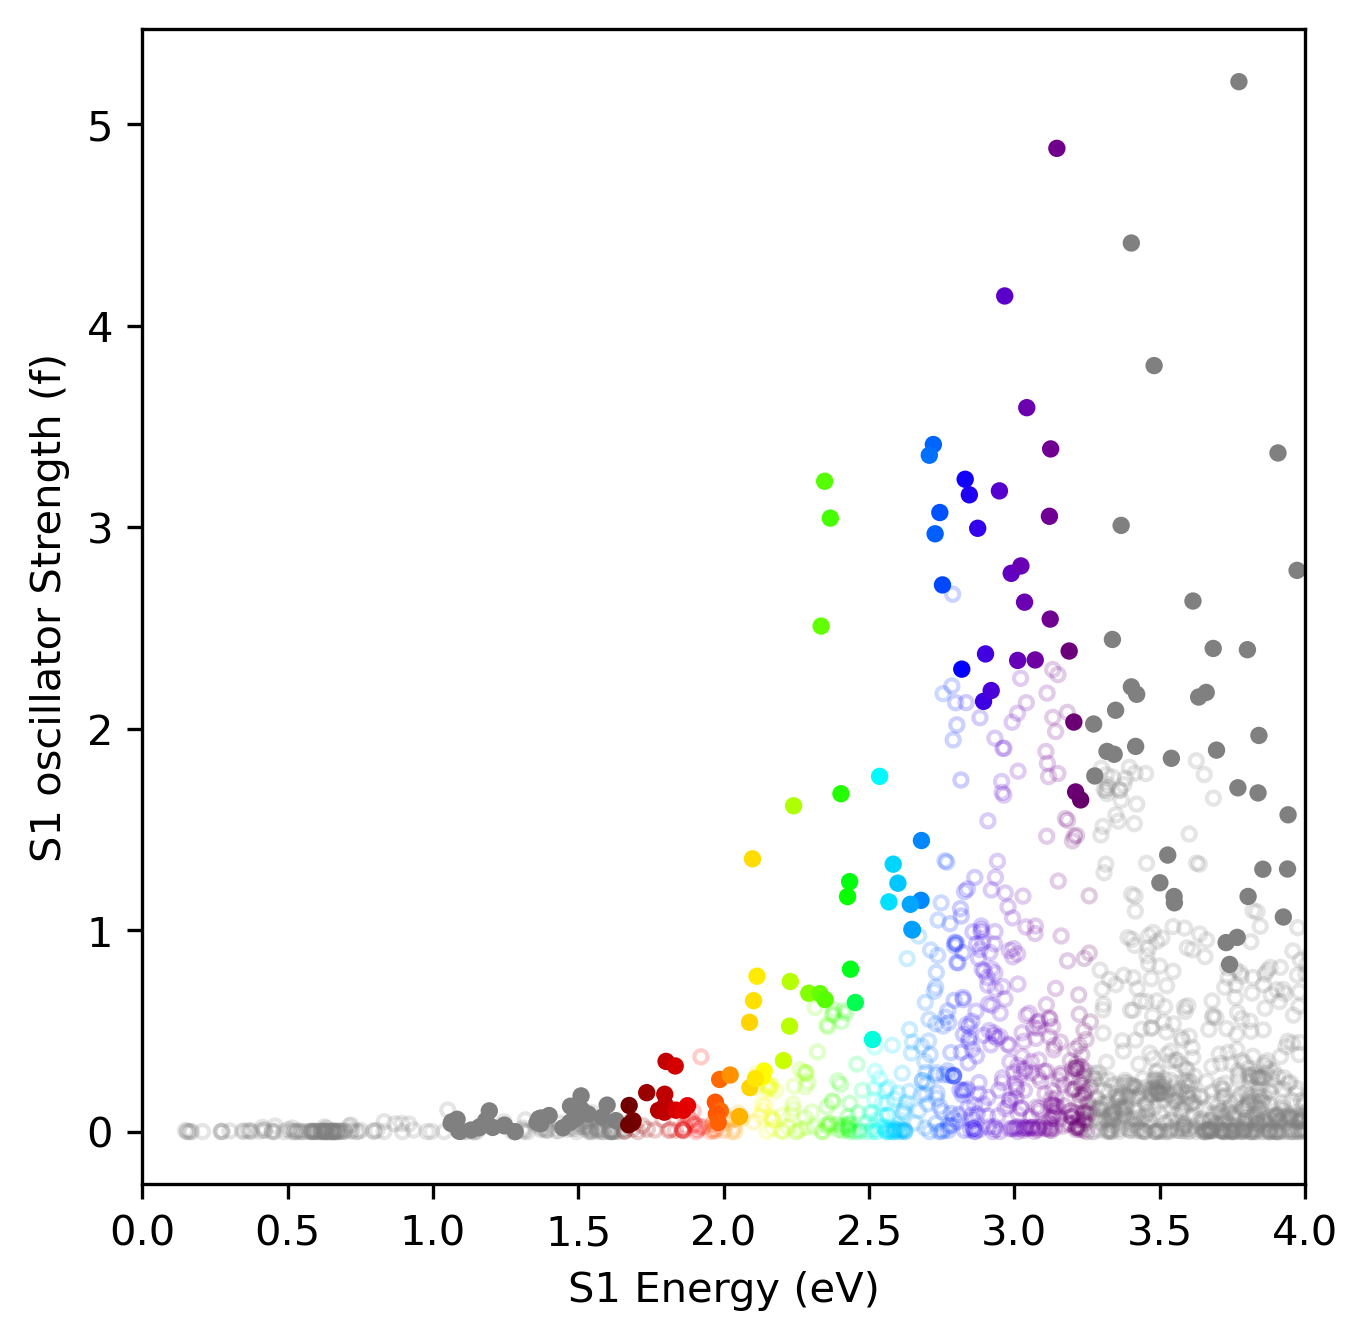

In [17]:
# Plot the downselected data and the rest of the data with lower alpha as we did before
rest_df = std2_df.merge(downselected_df[['partition', 'mol']], on=['partition', 'mol'], how='outer', indicator=True)
rest_df = rest_df[rest_df['_merge'] == 'left_only']
rest_df = rest_df.drop(columns=['_merge'])
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
# Plot rest of the data with lower alpha
lam_rest = 1239.841984 / rest_df['E_S1_eV'].values
colors_rest = [wavelength_to_rgb(w) for w in lam_rest]
ax.scatter(rest_df['E_S1_eV'], rest_df['f_osc_S1'], edgecolors=colors_rest, s=10, alpha=0.2, facecolors='none')
# Plot downselected data
lam_down = 1239.841984 / downselected_df['E_S1_eV'].values
colors_down = [wavelength_to_rgb(w) for w in lam_down]
ax.scatter(downselected_df['E_S1_eV'], downselected_df['f_osc_S1'], c=colors_down, s=10)
#ax.set_title('STD2 Dataset: Downselected S1 Energy vs Oscillator Strength')
ax.set_xlabel('S1 Energy (eV)')
ax.set_ylabel('S1 oscillator Strength (f)')
ax.set_xlim(0, 4.)
plt.show()
plt.close()

In [18]:
for index in range(len(downselected_df)):
    partition_str, mol_str = downselected_df.iloc[index]['partition'], downselected_df.iloc[index]['mol']
    crest_geom_p = os.path.join('compounds', partition_str, mol_str, 'crest', 'crest_best.xyz')

    target_p = os.path.join('downselected', mol_str, 'crest_best.xyz')
    os.makedirs(os.path.dirname(target_p), exist_ok=True)
    shutil.copy2(crest_geom_p, target_p)